# Exercise: Neural Networks

## 1. Import the required libraries in the cell below

In [11]:
import pandas as pd
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
from sklearn.preprocessing import StandardScaler
from keras.models import Sequential
from keras.layers import Dense, Input
from keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

## 2. Read the data

In [3]:
housing = pd.read_csv("./data/sacramento_real_estate_transactions.csv")
housing.head()

,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
0,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.631913,-121.434879
1,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.478902,-121.431028
2,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.618305,-121.443839
3,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.616835,-121.439146
4,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.519470,-121.435768


## 3. Conduct Exploratory Data Analysis 

In [4]:
# Check data info

housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 985 entries, 0 to 984
Data columns (total 12 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   street     985 non-null    str    
 1   city       985 non-null    str    
 2   zip        985 non-null    int64  
 3   state      985 non-null    str    
 4   beds       985 non-null    int64  
 5   baths      985 non-null    int64  
 6   sq__ft     985 non-null    int64  
 7   type       985 non-null    str    
 8   sale_date  985 non-null    str    
 9   price      985 non-null    int64  
 10  latitude   985 non-null    float64
 11  longitude  985 non-null    float64
dtypes: float64(2), int64(5), str(5)
memory usage: 156.9 KB


In [6]:
# Check for missing values
housing.isnull().sum()

street       0
city         0
zip          0
state        0
beds         0
baths        0
sq__ft       0
type         0
sale_date    0
price        0
latitude     0
longitude    0
dtype: int64

In [7]:
# Check data types
housing.dtypes

street           str
city             str
zip            int64
state            str
beds           int64
baths          int64
sq__ft         int64
type             str
sale_date        str
price          int64
latitude     float64
longitude    float64
dtype: object

In [8]:
# Look at the Summary Stats.
housing.describe()

,zip,beds,baths,sq__ft,price,latitude,longitude
count,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000,985.000000
mean,95750.697462,2.911675,1.776650,1312.918782,233715.951269,38.445121,-121.193371
std,85.176072,1.307932,0.895371,856.123224,139088.818896,5.103637,5.100670
min,95603.000000,0.000000,0.000000,-984.000000,-210944.000000,-121.503471,-121.551704
25%,95660.000000,2.000000,1.000000,950.000000,145000.000000,38.482704,-121.446119
50%,95762.000000,3.000000,2.000000,1304.000000,213750.000000,38.625932,-121.375799
75%,95828.000000,4.000000,2.000000,1718.000000,300000.000000,38.695589,-121.294893
max,95864.000000,8.000000,5.000000,5822.000000,884790.000000,39.020808,38.668433


In [ ]:
# Cleaning Steps (if needed)


In [46]:
housing = housing[
    (housing["sq__ft"] > 0)
    & (housing["beds"] > 0)
    & (housing["baths"] > 0)
    & (housing["price"] > 0)
    & (housing["latitude"].between(30, 45))]

In [47]:
housing["type"] = housing["type"].replace("Unkown", "Unknown")

In [48]:
housing = housing.reset_index(drop=True)

## 4. Split the Data & Pre-Processing
**Best Practice for Neural Network** Split your data before modeling into three part:

1. __The Training Set (The Textbook):__ This is the data the neural network actually looks at to learn. During the training loop, the network uses this data to adjust its **weights** and **biases** via backpropagation.

2. __The Validation Set (The Practice Quiz):__ This data evaluates the model *during* training to fine-tune settings. The model does not learn its weights from this data. Instead, the it uses the validation score to choose **hyperparameters** (like learning rate, number of layers, or node count) and to decide when to stop training (**early stopping**).


3. __The Test Set (The Final Exam):__ This data provides an unbiased, final evaluation of the model's real-world performance. This dataset is locked away until training is completely finished. It is only used *once* at the very end to see how well the network performs on truly unseen data.

__Typical Split Ratios__

Depending on the size of your total dataset, data scientists generally use these proportions:

| Dataset Size | Train | Validation | Test |
| :--- | :--- | :--- | :--- |
| **Traditional (Small/Medium Data)** | 60% | 20% | 20% |
| **Modern Deep Learning (Millions of Rows)** | 98% | 1% | 1% |

In [9]:
# Select the Features and Target
X = housing[["sq__ft"]]
y = housing["price"]

In [10]:
# Split to Train Test & Validation
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

In [12]:
# IMPORTANT: Scale the features for Neural Networks
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

## 5. Linear Regression

In [13]:
# Initialize LinearRegression model
lr_model = LinearRegression()

In [14]:
# Fit and check the Training Score
lr_model.fit(X_train, y_train)

print("Training R2:", lr_model.score(X_train, y_train))

Training R2: 0.09952895388538985


In [15]:
# Predict and check the Testing Score
y_pred = lr_model.predict(X_test)

print("Testing R2:", lr_model.score(X_test, y_test))

Testing R2: 0.04499695890064448


In [16]:
# Evaluate the model
# Coefficient 
print("Coefficient:", lr_model.coef_[0])

# Intercept

print("Intercept:", lr_model.intercept_)

# RMSE
rmse = root_mean_squared_error(y_test, y_pred)
print("RMSE:", rmse)

Coefficient: 51.51009037370924
Intercept: 159444.1313995469
RMSE: 146994.37172353125


## 6. Build a Single Neural Network
Creating a model in `keras` entails a few steps:
1. Create your network topology
2. Compile your model
3. Fit your model
   
**Important Note on Regression:**
Because we are predicting a continuous value (house price), our network is performing regression, not classification. 
* Your **hidden layers** should generally use the `relu` activation function.
* Your **output layer** must have exactly **1 neuron** and **no activation function** (or `activation='linear'`) so it can predict any continuous number.
* When compiling, use `loss='mse'` (Mean Squared Error) and `metrics=['mae']` (Mean Absolute Error) so we can see the error in actual dollar amounts.

In [18]:
# Step 1: Define

model = Sequential([
    Input(shape=(1,)),
    Dense(1, activation="linear")
])

# Step 2: Compile 
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 69285568512.0000 - mae: 227206.6875 - val_loss: 74117767168.0000 - val_mae: 233862.9844
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285560320.0000 - mae: 227206.6875 - val_loss: 74117758976.0000 - val_mae: 233862.9688
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285552128.0000 - mae: 227206.6406 - val_loss: 74117750784.0000 - val_mae: 233862.9688
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285535744.0000 - mae: 227206.6406 - val_loss: 74117734400.0000 - val_mae: 233862.9219
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285527552.0000 - mae: 227206.6094 - val_loss: 74117734400.0000 - val_mae: 233862.9062
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285519360.0000 - mae: 227206.6406 - val_loss: 74117718016.0000 - val_mae: 233862.8906
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 69285519360.0000 - mae: 227206.5781 - val_loss: 7411

In [19]:
# Model Weights
model.get_weights()

[array([[-0.15290911]], dtype=float32), array([1.889109], dtype=float32)]

In [20]:
# Model Summary
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8 (36.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6 (28.00 B)

## 7. Stacking Multiple Neurons

#### Shallow NN

In [21]:
# Step 1: Define

shallow_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])

# Step 2: Compile 

shallow_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit

shallow_history = shallow_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 69285339136.0000 - mae: 227206.5312 - val_loss: 74117382144.0000 - val_mae: 233862.6406
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 69285281792.0000 - mae: 227206.4219 - val_loss: 74117308416.0000 - val_mae: 233862.5156
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285208064.0000 - mae: 227206.2812 - val_loss: 74117251072.0000 - val_mae: 233862.3750
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285158912.0000 - mae: 227206.1406 - val_loss: 74117185536.0000 - val_mae: 233862.2500
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285093376.0000 - mae: 227206.0156 - val_loss: 74117111808.0000 - val_mae: 233862.1094
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 69285011456.0000 - mae: 227205.8438 - val_loss: 74117038080.0000 - val_mae: 233861.9219
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 69284937728.0000 - mae: 227205.7344 - val_loss: 7411

In [22]:
# Model Weights
shallow_model.get_weights()

[array([[-0.11239071,  2.9946322 , -2.5924735 ,  2.3350246 , -0.15597962,
          3.0330014 , -0.12212783,  1.1349403 ,  2.5307488 , -0.13726917]],
       dtype=float32),
 array([-0.18070516,  2.579394  ,  2.5560968 ,  2.5161343 , -0.24779344,
         2.6695745 , -0.20265299,  2.6110198 ,  2.5484686 , -0.22281738],
       dtype=float32),
 array([[-0.5331873 ],
        [ 2.936646  ],
        [ 3.2573373 ],
        [ 3.3097012 ],
        [-0.34133542],
        [ 2.79575   ],
        [-0.51249534],
        [ 3.3227239 ],
        [ 3.1558828 ],
        [-0.5755236 ]], dtype=float32),
 array([1.8905414], dtype=float32)]

In [23]:
# Model Summary
shallow_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

#### Deep Network

In [25]:
# use multiple hidden layers with different neurons

# Step 1: Define
deep_model = Sequential([
    Input(shape=(1,)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(1)
])

# Step 2: Compile 
deep_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Step 3: Fit
deep_history = deep_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 69285486592.0000 - mae: 227206.7188 - val_loss: 74117586944.0000 - val_mae: 233862.9219
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285462016.0000 - mae: 227206.6875 - val_loss: 74117570560.0000 - val_mae: 233862.8906
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 69285445632.0000 - mae: 227206.6094 - val_loss: 74117521408.0000 - val_mae: 233862.7969
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 69285388288.0000 - mae: 227206.5000 - val_loss: 74117464064.0000 - val_mae: 233862.7031
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 69285330944.0000 - mae: 227206.3906 - val_loss: 74117373952.0000 - val_mae: 233862.5156
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285216256.0000 - mae: 227206.1719 - val_loss: 74117251072.0000 - val_mae: 233862.2812
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 69285093376.0000 - mae: 227205.9219 - val_loss: 7411

In [26]:
# Model Weights
deep_model.get_weights()

[array([[ 5.7027477e-01,  3.3998921e+00, -2.5029695e+00, -8.2894482e-02,
          3.6706703e+00, -1.3412752e-03, -2.2419939e+00,  3.7873294e+00,
         -2.3486302e+00, -2.8010349e+00, -1.6481656e-01,  3.4964416e+00,
         -1.9044708e+00,  3.2587724e+00,  3.4818230e+00, -2.5763052e+00,
          3.3220720e+00, -2.7674799e+00,  3.5189574e+00, -2.6016679e+00,
         -2.9304790e+00, -2.9051578e+00, -1.6095905e+00,  7.2825575e-01,
          3.7716858e+00, -2.7326107e+00, -2.7863698e+00,  3.8748250e+00,
          3.5853209e+00,  1.3790295e+00, -6.7127788e-01, -2.8647430e+00]],
       dtype=float32),
 array([ 3.6872551 ,  3.4392738 ,  3.5772302 ,  3.7168145 ,  3.7266653 ,
        -0.01847449,  3.6637983 ,  3.7462778 ,  3.6721578 ,  3.4586086 ,
        -0.27359337,  3.713891  ,  3.780258  ,  3.4800327 ,  3.781495  ,
         3.8383875 ,  3.4599893 ,  3.53323   ,  3.670544  ,  3.629357  ,
         3.6409092 ,  3.6532798 ,  3.6987805 ,  3.737337  ,  3.8493574 ,
         3.762351  ,  3.69

In [29]:
# Model Summary
deep_model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_13 (Dense)                     │ (None, 32)                  │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_14 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,213 (8.65 KB)

 Trainable params: 737 (2.88 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,476 (5.77 KB)

## 8. Activation Functions

In [28]:
# from keras.layers import Activation 
# Note: import Activation if you use it as a standalone layer
# Step 1: Define
activation_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="sigmoid"),
    Dense(1)
])


# Step 2: Compile 
activation_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


# Step 3: Fit
activation_history = activation_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 69285044224.0000 - mae: 227205.7344 - val_loss: 74117095424.0000 - val_mae: 233861.9062
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 69284978688.0000 - mae: 227205.6250 - val_loss: 74117046272.0000 - val_mae: 233861.7656
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 69284929536.0000 - mae: 227205.5000 - val_loss: 74116980736.0000 - val_mae: 233861.6406
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 69284864000.0000 - mae: 227205.3594 - val_loss: 74116915200.0000 - val_mae: 233861.4844
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 69284798464.0000 - mae: 227205.2188 - val_loss: 74116857856.0000 - val_mae: 233861.3594
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 69284732928.0000 - mae: 227205.0938 - val_loss: 74116784128.0000 - val_mae: 233861.2188
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 69284683776.0000 - mae: 227204.9844 - val_loss: 7411

In [32]:
# Model Weights
activation_model.get_weights()

[array([[0.19311447, 0.19907373, 0.19028707, 0.19935144, 0.13407506,
         0.1875336 , 0.18730289, 0.19925627, 0.18766257, 0.20758255]],
       dtype=float32),
 array([2.1467934, 2.1619225, 2.2221704, 2.1962907, 1.0899704, 2.3215764,
        2.3299673, 2.1665518, 2.364673 , 2.0601432], dtype=float32),
 array([[2.5817285],
        [2.5010054],
        [2.4152699],
        [2.4531598],
        [1.3684981],
        [2.028107 ],
        [2.244643 ],
        [2.4929538],
        [2.0277612],
        [2.794189 ]], dtype=float32),
 array([1.8896916], dtype=float32)]

In [34]:
# Model Summary
activation_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

## 9. Epochs

In [31]:
# Step 1: Define
epoch_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])

# Step 2: Compile 
epoch_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
epoch_history = epoch_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    batch_size=32,
    verbose=1
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 32ms/step - loss: 69285560320.0000 - mae: 227206.8438 - val_loss: 74117644288.0000 - val_mae: 233863.0000
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285511168.0000 - mae: 227206.7656 - val_loss: 74117595136.0000 - val_mae: 233862.9375
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285462016.0000 - mae: 227206.6875 - val_loss: 74117537792.0000 - val_mae: 233862.8281
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285412864.0000 - mae: 227206.5781 - val_loss: 74117496832.0000 - val_mae: 233862.7344
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285363712.0000 - mae: 227206.4688 - val_loss: 74117439488.0000 - val_mae: 233862.6250
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 69285314560.0000 - mae: 227206.3594 - val_loss: 74117382144.0000 - val_mae: 233862.5156
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 69285257216.0000 - mae: 227206.2500 - val_loss: 7411

In [36]:
# Model Weights
epoch_model.get_weights()

[array([[ 4.0248647 ,  2.1413608 ,  4.6661053 , -0.12494041,  4.635284  ,
          5.106985  ,  5.2965264 , -3.3086922 ,  2.0504265 , -0.14741808]],
       dtype=float32),
 array([ 3.8576522 ,  5.2245126 ,  4.9610558 , -0.21791828,  4.9990172 ,
         5.3486743 ,  5.347206  ,  5.3860373 ,  5.192771  , -0.23921123],
       dtype=float32),
 array([[ 4.145034  ],
        [ 5.561307  ],
        [ 5.6044335 ],
        [-0.6665359 ],
        [ 5.571045  ],
        [ 5.0895996 ],
        [ 4.9807115 ],
        [ 5.2009974 ],
        [ 5.6174536 ],
        [-0.44950882]], dtype=float32),
 array([3.7770357], dtype=float32)]

In [37]:
# Model Summary
epoch_model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_19 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

## 10. Batch size (Chunks)

In [38]:
# Use the validation
# Step 1: Define
batch_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])


# Step 2: Compile 
batch_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
batch_history = batch_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=64,
    verbose=1
)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 71ms/step - loss: 69285486592.0000 - mae: 227206.7656 - val_loss: 74117562368.0000 - val_mae: 233862.9375
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 69285462016.0000 - mae: 227206.7188 - val_loss: 74117521408.0000 - val_mae: 233862.8906
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 69285429248.0000 - mae: 227206.6562 - val_loss: 74117496832.0000 - val_mae: 233862.8281
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 69285412864.0000 - mae: 227206.5781 - val_loss: 74117464064.0000 - val_mae: 233862.7656
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 69285363712.0000 - mae: 227206.5469 - val_loss: 74117431296.0000 - val_mae: 233862.7031
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 69285339136.0000 - mae: 227206.4688 - val_loss: 74117398528.0000 - val_mae: 233862.6562
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 69285306368.0000 - mae: 227206.4375 - val_loss: 7411

In [39]:
# Model Weights
batch_model.get_weights()

[array([[ 1.366851  , -0.18780087,  0.08901608,  0.04438765,  1.6063321 ,
         -1.2877015 ,  1.723494  , -1.0644193 , -1.46122   ,  1.5376966 ]],
       dtype=float32),
 array([ 1.0672013 , -0.2999354 , -0.32934374, -0.17175351,  1.3181064 ,
         1.1798298 ,  1.2909827 ,  1.4758221 ,  1.1806313 ,  1.3371454 ],
       dtype=float32),
 array([[ 1.1633773 ],
        [-0.24530855],
        [-0.31352645],
        [-0.31576785],
        [ 1.8695738 ],
        [ 1.2235174 ],
        [ 1.9431621 ],
        [ 1.6957389 ],
        [ 1.1734607 ],
        [ 1.8317404 ]], dtype=float32),
 array([0.9962648], dtype=float32)]

In [40]:
# Model Summary
batch_model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_21 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

Try a different batch size. 

__Note:__ the best practice to have the value in powers of 2

In [41]:
# Use the validation
# Step 1: Define
batch_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])


# Step 2: Compile 
batch_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
batch_history = batch_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size= 32,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - loss: 69285429248.0000 - mae: 227206.6094 - val_loss: 74117521408.0000 - val_mae: 233862.7812
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 69285371904.0000 - mae: 227206.5000 - val_loss: 74117464064.0000 - val_mae: 233862.6875
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 69285330944.0000 - mae: 227206.3906 - val_loss: 74117406720.0000 - val_mae: 233862.5625
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285265408.0000 - mae: 227206.3125 - val_loss: 74117349376.0000 - val_mae: 233862.4531
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285216256.0000 - mae: 227206.2031 - val_loss: 74117283840.0000 - val_mae: 233862.3594
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285150720.0000 - mae: 227206.0938 - val_loss: 74117218304.0000 - val_mae: 233862.2500
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285093376.0000 - mae: 227205.9844 - val_loss: 7411

In [42]:
# Model Weights
batch_model.get_weights()

[array([[ 2.3778474e+00,  2.3074880e+00,  3.1891937e+00, -2.2136921e-03,
         -1.3575388e-02,  3.0373745e+00, -2.6890934e+00,  2.2776291e-02,
         -2.4844902e+00,  7.8819565e-02]], dtype=float32),
 array([ 2.482973  ,  2.5010443 ,  2.9237204 , -0.00765192, -0.04665707,
         2.6821198 ,  2.6549213 , -0.09458965,  2.7843077 , -0.30034834],
       dtype=float32),
 array([[ 3.3439193 ],
        [ 3.3390036 ],
        [ 2.5610237 ],
        [ 0.00688554],
        [-0.6056704 ],
        [ 2.7635815 ],
        [ 2.981954  ],
        [-0.63546884],
        [ 2.6077325 ],
        [-0.433011  ]], dtype=float32),
 array([1.8897835], dtype=float32)]

In [44]:
# Model Summary
batch_model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

## 11. History

**The Three Main Reasons to Use History**
  1. To Spot Overfitting
  2. To Visualise the Learning Curve
  3. To Know When to Stop Training

By saving the output of `model.fit()` to a variable (usually called `history`), Keras keeps a record of the training loss and validation loss at the end of each epoch. 

Plotting these two lines together helps us diagnose our model:
* If training loss goes down but validation loss goes up, the model is **overfitting** (memorizing the training data).
* If both are going down, the model is still learning.
* If both have flattened out, the model has converged and stopped learning.

In [49]:
# Use the validation
# Step 1: Define
history_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])

# Step 2: Compile
history_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
history = history_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    verbose=1
)

Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 69285347328.0000 - mae: 227206.5000 - val_loss: 74117431296.0000 - val_mae: 233862.6406
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285306368.0000 - mae: 227206.3906 - val_loss: 74117398528.0000 - val_mae: 233862.5312
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 69285265408.0000 - mae: 227206.2812 - val_loss: 74117349376.0000 - val_mae: 233862.4375
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285208064.0000 - mae: 227206.2031 - val_loss: 74117300224.0000 - val_mae: 233862.3594
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285167104.0000 - mae: 227206.0625 - val_loss: 74117251072.0000 - val_mae: 233862.2188
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 69285109760.0000 - mae: 227205.9531 - val_loss: 74117185536.0000 - val_mae: 233862.0938
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285044224.0000 - mae: 227205.8281 - val_loss: 7411

In [55]:
# Model Weights
history_model.get_weights()

[array([[ 2.5562942 , -2.4713907 , -0.00392128,  0.85290354,  2.5632172 ,
         -2.5371864 , -2.4126894 , -0.14716962, -2.3964407 , -0.07297211]],
       dtype=float32),
 array([ 2.5533915 ,  2.915944  , -0.01611939,  2.5482774 ,  2.5636818 ,
         2.8203099 ,  2.5884128 , -0.23698744,  2.7345536 , -0.12160905],
       dtype=float32),
 array([[ 3.1261847 ],
        [ 2.7064767 ],
        [-0.39046034],
        [ 3.5736978 ],
        [ 3.1052384 ],
        [ 2.6169994 ],
        [ 3.2081077 ],
        [-0.12185153],
        [ 2.9168522 ],
        [-0.67770225]], dtype=float32),
 array([1.8874733], dtype=float32)]

In [52]:
# Model Summary
history_model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_25 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [53]:
# Create a History Data Frame
history_df = pd.DataFrame(history.history)
history_df.head()

,loss,mae,val_loss,val_mae
0,6.928535e+10,227206.500000,7.411743e+10,233862.640625
1,6.928531e+10,227206.390625,7.411740e+10,233862.531250
2,6.928527e+10,227206.281250,7.411735e+10,233862.437500
3,6.928521e+10,227206.203125,7.411730e+10,233862.359375
4,6.928517e+10,227206.062500,7.411725e+10,233862.218750


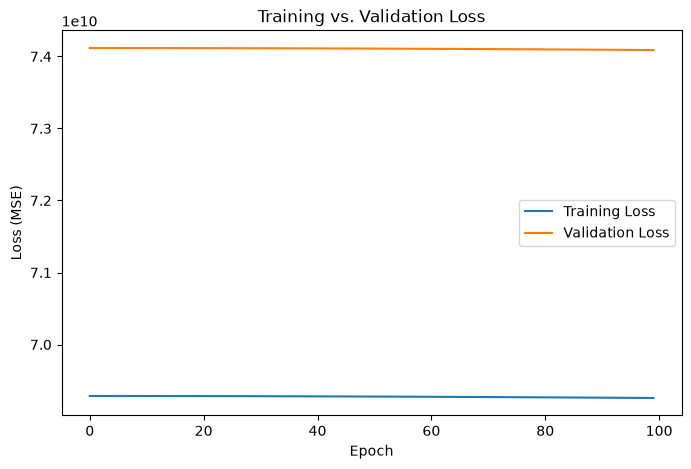

In [54]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="Training Loss")
plt.plot(history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Training vs. Validation Loss")
plt.legend()
plt.show()


## 12. Early Stopping (callback)

- Prevent overfitting
- will not waste the computing power
- save time
  
It is hard to guess exactly how many epochs a model needs. If you train for too few epochs, the model underfits. If you train for too many, it overfits. 

An **Early Stopping Callback** acts as an automatic brake. It monitors the validation loss and automatically stops training once the validation score stops improving, even if you haven't reached your maximum number of epochs. It can also automatically restore the model's best weights!

In [56]:
# configure EarlyStopping parameters
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)


In [58]:
# Use the validation
# Step 1: Define
es_model = Sequential([
    Input(shape=(1,)),
    Dense(10, activation="relu"),
    Dense(1)
])

# Step 2: Compile
es_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
es_history = es_model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 3s 37ms/step - loss: 69285347328.0000 - mae: 227206.4375 - val_loss: 74117447680.0000 - val_mae: 233862.6250
Epoch 2/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 69285306368.0000 - mae: 227206.3281 - val_loss: 74117398528.0000 - val_mae: 233862.5156
Epoch 3/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285257216.0000 - mae: 227206.2344 - val_loss: 74117341184.0000 - val_mae: 233862.3906
Epoch 4/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 69285199872.0000 - mae: 227206.1250 - val_loss: 74117292032.0000 - val_mae: 233862.2812
Epoch 5/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 69285142528.0000 - mae: 227205.9844 - val_loss: 74117234688.0000 - val_mae: 233862.1250
Epoch 6/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 69285068800.0000 - mae: 227205.8438 - val_loss: 74117177344.0000 - val_mae: 233862.0156
Epoch 7/100
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 69285011456.0000 - mae: 227205.7344 - val_loss: 7411

In [59]:
# Model Weights
es_model.get_weights()

[array([[ 2.7651284 , -2.111922  ,  0.57023144,  0.04909384,  2.6718395 ,
         -2.1943064 , -1.4693485 , -2.1370633 , -2.8138926 , -0.17174235]],
       dtype=float32),
 array([ 2.7993011 ,  2.601379  ,  2.8070865 , -0.18944709,  2.4776478 ,
         2.6898541 ,  2.6446831 ,  2.5817595 ,  2.8521376 , -0.2736333 ],
       dtype=float32),
 array([[ 2.7282004 ],
        [ 3.2518659 ],
        [ 3.0487356 ],
        [-0.58733755],
        [ 3.2732563 ],
        [ 2.6250217 ],
        [ 3.2262924 ],
        [ 3.301842  ],
        [ 2.686948  ],
        [-0.11599951]], dtype=float32),
 array([1.8893764], dtype=float32)]

In [60]:
# Model Summary
es_model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ (None, 10)                  │              20 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

In [61]:
# Create a History Data Frame
es_history_df = pd.DataFrame(es_history.history)
es_history_df.head()


,loss,mae,val_loss,val_mae
0,6.928535e+10,227206.437500,7.411745e+10,233862.625000
1,6.928531e+10,227206.328125,7.411740e+10,233862.515625
2,6.928526e+10,227206.234375,7.411734e+10,233862.390625
3,6.928520e+10,227206.125000,7.411729e+10,233862.281250
4,6.928514e+10,227205.984375,7.411723e+10,233862.125000


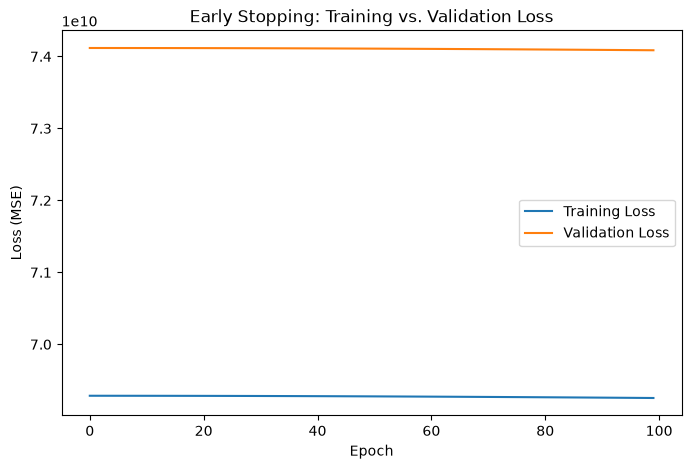

In [62]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss
plt.figure(figsize=(8, 5))
plt.plot(es_history_df["loss"], label="Training Loss")
plt.plot(es_history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Early Stopping: Training vs. Validation Loss")
plt.legend()
plt.show()


## 13.Multi-Feature Neural Network

In [63]:
# configure EarlyStopping parameters
early_stop_multi = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

In [65]:
# Select multiple features this time
X_multi = housing[["sq__ft", "beds", "baths"]]
y_multi = housing["price"]

# Split into train / validation / test
X_multi_train, X_multi_temp, y_multi_train, y_multi_temp = train_test_split(
    X_multi, y_multi, test_size=0.40, random_state=42
)
X_multi_val, X_multi_test, y_multi_val, y_multi_test = train_test_split(
    X_multi_temp, y_multi_temp, test_size=0.50, random_state=42
)

# Scale the features (fit only on training data)
multi_scaler = StandardScaler()
X_multi_train_scaled = multi_scaler.fit_transform(X_multi_train)
X_multi_val_scaled = multi_scaler.transform(X_multi_val)
X_multi_test_scaled = multi_scaler.transform(X_multi_test)

# Use the validation
# Step 1: Define
multi_model = Sequential([
    Input(shape=(X_multi_train_scaled.shape[1],)),
    Dense(32, activation="relu"),
    Dense(16, activation="relu"),
    Dense(1)
])

# Step 2: Compile
multi_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

# Step 3: Fit
multi_history = multi_model.fit(
    X_multi_train_scaled,
    y_multi_train,
    validation_data=(X_multi_val_scaled, y_multi_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop_multi],
    verbose=1
)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step - loss: 71301799936.0000 - mae: 236056.3594 - val_loss: 66147803136.0000 - val_mae: 228550.5312
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 71301644288.0000 - mae: 236056.1094 - val_loss: 66147700736.0000 - val_mae: 228550.3125
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 71301513216.0000 - mae: 236055.8750 - val_loss: 66147602432.0000 - val_mae: 228550.1406
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 71301373952.0000 - mae: 236055.6406 - val_loss: 66147479552.0000 - val_mae: 228549.8906
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 71301210112.0000 - mae: 236055.3750 - val_loss: 66147328000.0000 - val_mae: 228549.5938
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 71301005312.0000 - mae: 236054.9688 - val_loss: 66147127296.0000 - val_mae: 228549.2031
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 71300726784.0000 - mae: 236054.4688 - val_loss: 6614

In [66]:
# Model Weights
multi_model.get_weights()


[array([[ 2.116315  ,  2.5713825 ,  2.690766  ,  2.448555  ,  2.4814694 ,
          2.6456187 ,  2.6156042 ,  0.00611923,  2.2341306 ,  2.6113641 ,
         -2.9062657 , -2.8732083 ,  2.4927402 ,  2.6075518 , -3.084888  ,
          2.0116503 ,  2.6167955 ,  2.6648338 ,  2.0517542 , -2.8683984 ,
         -2.9717789 , -2.8311417 , -2.885312  ,  2.6349053 , -2.7091465 ,
          2.4066355 ,  2.630861  ,  2.756944  ,  2.3745267 ,  2.8150213 ,
         -3.0047503 , -3.116183  ],
        [ 2.7033238 ,  2.3901465 ,  2.0662124 ,  2.2110507 ,  2.422601  ,
          2.173685  ,  2.7058723 ,  0.013584  ,  2.4929504 ,  2.6767695 ,
         -2.646339  , -1.9774523 ,  2.3705223 ,  2.5493073 , -2.922194  ,
          2.2564535 ,  2.6612096 ,  2.9021645 ,  2.6831245 , -2.6950414 ,
         -2.820743  , -2.8368754 , -2.781834  ,  2.7448132 , -2.8330042 ,
          2.7811298 ,  2.5612514 ,  2.4256856 ,  2.7133608 ,  2.6709735 ,
         -2.5346615 , -2.5980256 ],
        [ 2.9029174 ,  2.2848747 ,  2.60

In [67]:
# Model Summary
multi_model.summary()

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                     │ (None, 32)                  │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_35 (Dense)                     │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_36 (Dense)                     │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,021 (7.90 KB)

 Trainable params: 673 (2.63 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,348 (5.27 KB)

In [68]:
# Create a History Data Frame
multi_history_df = pd.DataFrame(multi_history.history)
multi_history_df.head()

,loss,mae,val_loss,val_mae
0,7.130180e+10,236056.359375,6.614780e+10,228550.531250
1,7.130164e+10,236056.109375,6.614770e+10,228550.312500
2,7.130151e+10,236055.875000,6.614760e+10,228550.140625
3,7.130137e+10,236055.640625,6.614748e+10,228549.890625
4,7.130121e+10,236055.375000,6.614733e+10,228549.593750


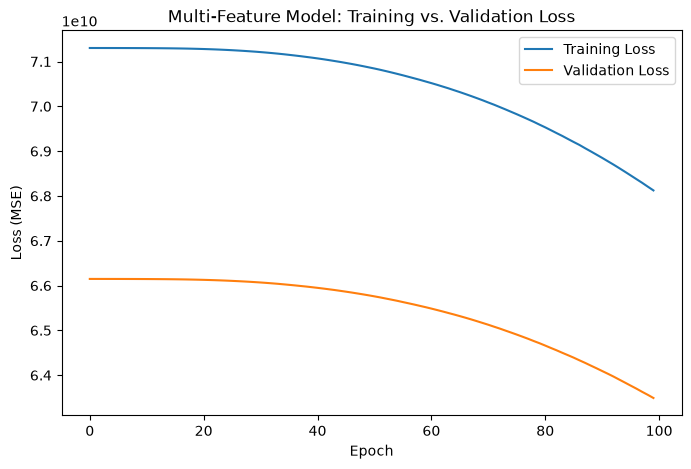

In [69]:
# Visualize Epochs vs. Loss for the Training Loss and Validation Loss

plt.figure(figsize=(8, 5))
plt.plot(multi_history_df["loss"], label="Training Loss")
plt.plot(multi_history_df["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Multi-Feature Model: Training vs. Validation Loss")
plt.legend()
plt.show()
